<a href="https://colab.research.google.com/github/cjsnhope/Systems-Biology/blob/main/SB__AS4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

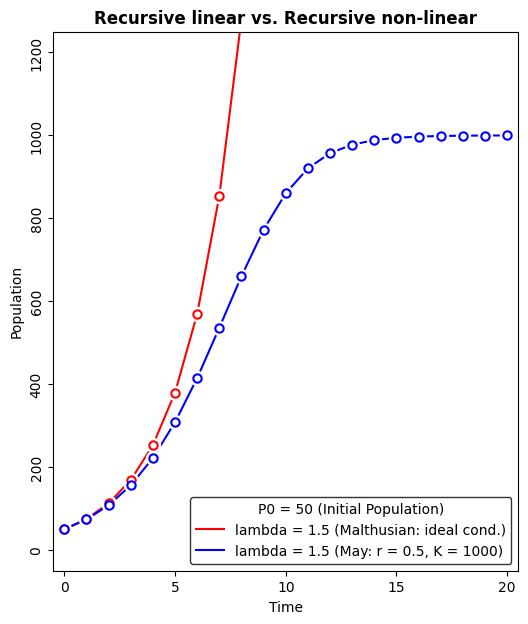

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Part 1. Comparing the Malthusian and the May model

def Malthusian_May():

    # Initial conditions provided in the assignment
    P0 = 50          # Initial population
    lam = 1.5        # Finite growth rate (lambda)
    r = lam - 1      # Intrinsic growth rate for May model
    K = 1000         # Carrying capacity
    ntime = 20       # Number of reproduction cycles

    # Initialize vectors to store population history
    vP1 = [P0]       # Malthusian model results
    vP2 = [P0]       # May model results

    curr_P1 = P0
    curr_P2 = P0

    # Recursive simulation loop
    for i in range(ntime):

        # 1. Malthusian model: P_t+1 = lambda * P_t
        curr_P1 = lam * curr_P1
        vP1.append(curr_P1)

        # 2. May model: P_t+1 = P_t + r * P_t * (1 - P_t / K)
        curr_P2 = curr_P2 + r * curr_P2 * (1 - curr_P2 / K)
        vP2.append(curr_P2)

    # Plotting the results
    plt.figure(figsize=(6, 7))
    time_steps = np.arange(ntime + 1)

    # Red for Malthusian model
    plt.plot(time_steps, vP1, color='red', linestyle='-', zorder=1)
    plt.plot(time_steps, vP1, 'wo', markersize=10, zorder=2)
    plt.plot(time_steps, vP1, 'ro', mfc='white', markersize=6, mew=1.5, zorder=3)

    # Blue for May model
    plt.plot(time_steps, vP2, color='blue', linestyle='-', zorder=1)
    plt.plot(time_steps, vP2, 'wo', markersize=10, zorder=2)
    plt.plot(time_steps, vP2, 'bo', mfc='white', markersize=6, mew=1.5, zorder=3)

    # Set the ranges of axis
    plt.xlim(-0.5, 20.5)
    plt.ylim(-50, 1250)

    # Set the ticks of axis
    plt.xticks(np.arange(0, 21, 5))
    plt.yticks(np.arange(0, 1201, 200), rotation=90, va='center')

    # Set axis labels and title
    plt.xlabel('Time')
    plt.ylabel('Population')
    plt.title('Recursive linear vs. Recursive non-linear', fontweight='bold')

    # Add legend with required values
    handle1 = plt.Line2D([], [], color='red', label=f'lambda = {lam} (Malthusian: ideal cond.)')
    handle2 = plt.Line2D([], [], color='blue', label=f'lambda = {lam} (May: r = {r}, K = {K})')
    plt.legend(handles=[handle1, handle2], title=f'P0 = {P0} (Initial Population)', loc='lower right', frameon=True, edgecolor='black')

    plt.show()


Malthusian_May()


In [47]:
# Part 2. Simulate the May model with Cobweb plot function

# Function to draw a population growth curve and a cobweb plot
def Cobweb(r, P0, K, x_range_max):

    ntime = 100  # Run at least 100 reproduction cycles

    # Simulate the May model
    pop_history = [P0]
    curr_P = P0
    for _ in range(ntime):
        curr_P = curr_P + r * curr_P * (1 - curr_P / K)
        pop_history.append(curr_P)

    # Prepare for plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))
    plt.subplots_adjust(hspace=0.4)

    # --- Plot 1: Growth Curve ---

    ax1.plot(range(ntime + 1), pop_history, color='blue', linewidth=1)

    # Set the labels
    ax1.set_title('The May model', fontweight='bold')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Population')

    # Set the range
    ax1.set_ylim(-50, 1250)

    # Set the ticks
    ticks_1 = range(0, 1201, 200)
    tick_labels_1 = [str(t) if t % 400 == 0 else "" for t in ticks_1]
    ax1.set_yticks(ticks_1, labels=tick_labels_1, va='center', rotation=90)

    # Set the legend
    leg_may = plt.Line2D([0], [0], color='blue', linestyle='-', linewidth=1)
    ax1.legend(handles=[leg_may], labels=[f"r: {r}, P0: {float(P0)}, K: {K}"], loc='lower right', bbox_to_anchor=(1, 0),
               borderaxespad=0, fancybox=False, frameon=True, edgecolor='black', borderpad=1)


    # --- Plot 2: Cobweb Plot ---


    # Define the range for the plot
    x_limit = x_range_max
    x = np.linspace(0, x_limit, 500)

    # Growth function: f(P) = P + r*P*(1-P/K)
    y = x + r * x * (1 - x / K)

    ax2.plot(x, y, 'b-', label='May model curve', linewidth=1) # Curve
    ax2.plot([0, x_limit], [0, x_limit], 'k--', linewidth=0.8) # Diagonal line (y=x)

    # Draw trajectory lines (staircase/cobweb)
    curr_P = P0
    for i in range(ntime):
        # f(P_t) = P_t + r*P_t*(1-P_t/K)
        next_P = curr_P + r * curr_P * (1 - curr_P / K)

        # Vertical line from (P_t, P_t) to (P_t, P_t+1)
        ax2.plot([curr_P, curr_P], [curr_P, next_P], 'k-', linewidth=0.5)
        # Horizontal line from (P_t, P_t+1) to (P_t+1, P_t+1)
        ax2.plot([curr_P, next_P], [next_P, next_P], 'k-', linewidth=0.5)

        curr_P = next_P

    # Set the labels
    ax2.set_title('Cobweb plot of the model above', fontweight='bold')
    ax2.set_xlabel('$\mathrm{P_t}$')
    ax2.set_ylabel('$\mathrm{P_{t+1}}$')

    # Set the axis ranges
    padding = x_limit * 0.05
    ax2.set_xlim(-padding, x_limit + padding)
    ax2.set_ylim(-padding, x_limit + padding)

    # Set the ticks
    ticks_2 = range(0, 1401, 200)
    tick_labels_2 = [str(t) if t % 400 == 0 else "" for t in ticks_2]
    ax2.set_yticks(ticks_2, labels=tick_labels_2, va='center', rotation=90)

    plt.show()


<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:71: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:71: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4633/1987583256.py:70: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_xlabel('$\mathrm{P_t}$')
/tmp/ipykernel_4633/1987583256.py:71: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('$\mathrm{P_{t+1}}$')


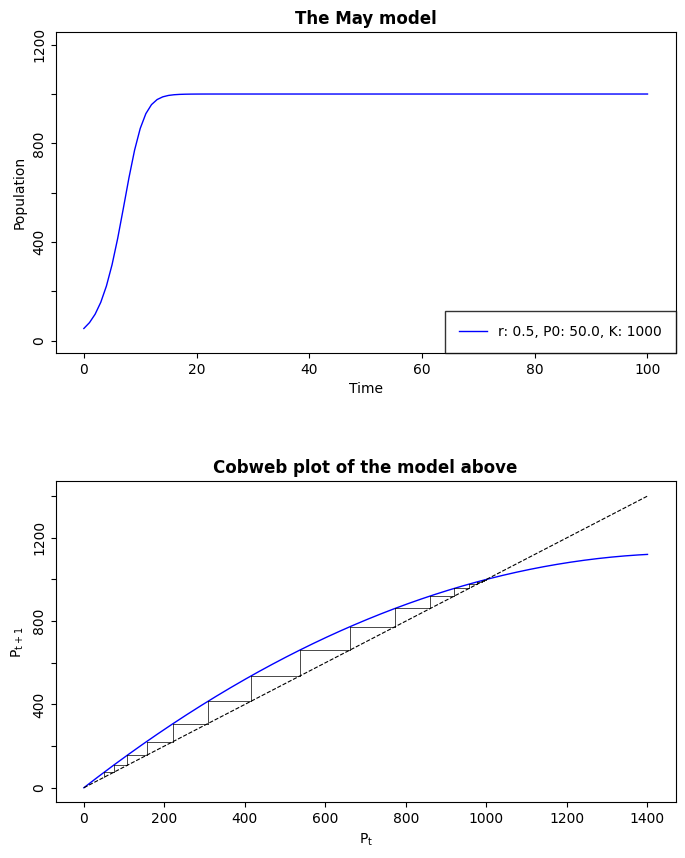

In [48]:
# r=0.5
Cobweb(r=0.5, P0=50, K=1000, x_range_max=1400)

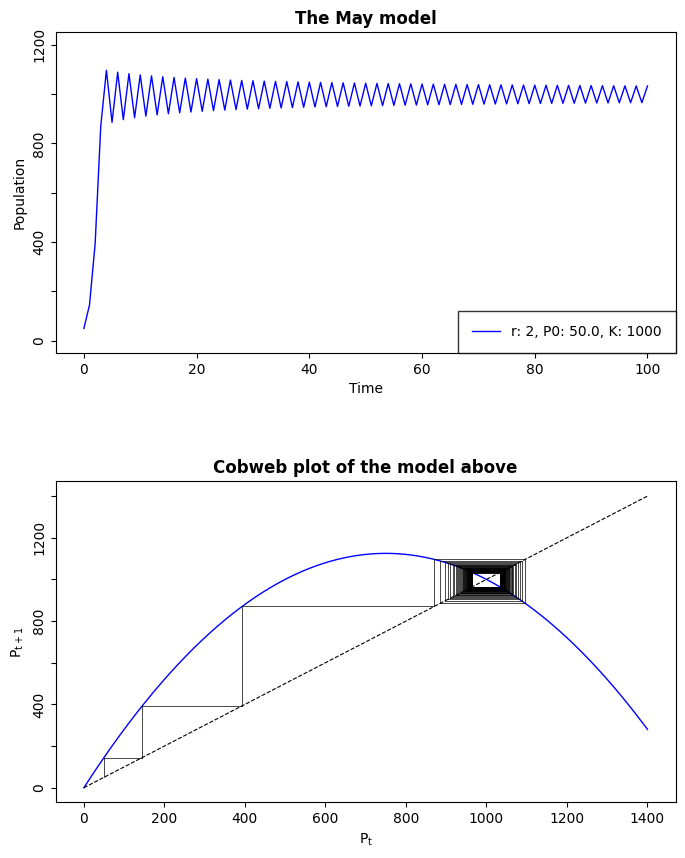

In [49]:
# r=2.0
Cobweb(r=2, P0=50, K=1000, x_range_max=1400)